# Arithmetic Accuracy Reviewer Revisions

This notebook implements the confirmed revise-and-resubmit work for Tables 2–4 and Figures 4, 5, and 9 while preserving the seven original notebooks and the manuscript. It uses the checksum-verified `2025-11-ArchivalCopyofArticleData` snapshot.

Definitions used throughout:

- **Arithmetic difference:** printed subtotal minus the sum of the transcribed parish counts.
- **Comparable week:** both values are numeric and available for the same year, week, and count type.
- **Legible week:** no parish count or printed subtotal in that weekly bill is marked illegible.
- **Annual arithmetic-error rate:** percentage of comparable burial weeks whose arithmetic difference is nonzero.


## Environment and data

Local execution uses `uv sync` followed by `uv run jupyter lab`. In Colab, follow the sparse-clone and `%pip install` commands in `README.md`. The loader uses complete local Git LFS files when available; otherwise it downloads immutable, pinned objects into `data-cache/` and verifies their byte sizes and SHA-256 digests.


Archived data commit: 9d0614c6c6ca134c734472b7a56fb4a14f4f8be0
all_bills.csv: /Users/jheppler/work/chnm/bom/bom-processing/notebooks/arithmetic-accuracy/data-cache/all_bills.csv
weeks.csv: /Users/jheppler/work/chnm/bom/bom-processing/notebooks/arithmetic-accuracy/data-cache/weeks.csv
parishes.csv: /Users/jheppler/work/chnm/bom/bom-processing/notebooks/arithmetic-accuracy/data-cache/parishes.csv
subtotals.csv: /Users/jheppler/work/chnm/bom/bom-processing/notebooks/arithmetic-accuracy/data-cache/subtotals.csv
duplicate_bills_removable.csv: /Users/jheppler/work/chnm/bom/bom-processing/notebooks/arithmetic-accuracy/data-cache/duplicate_bills_removable.csv


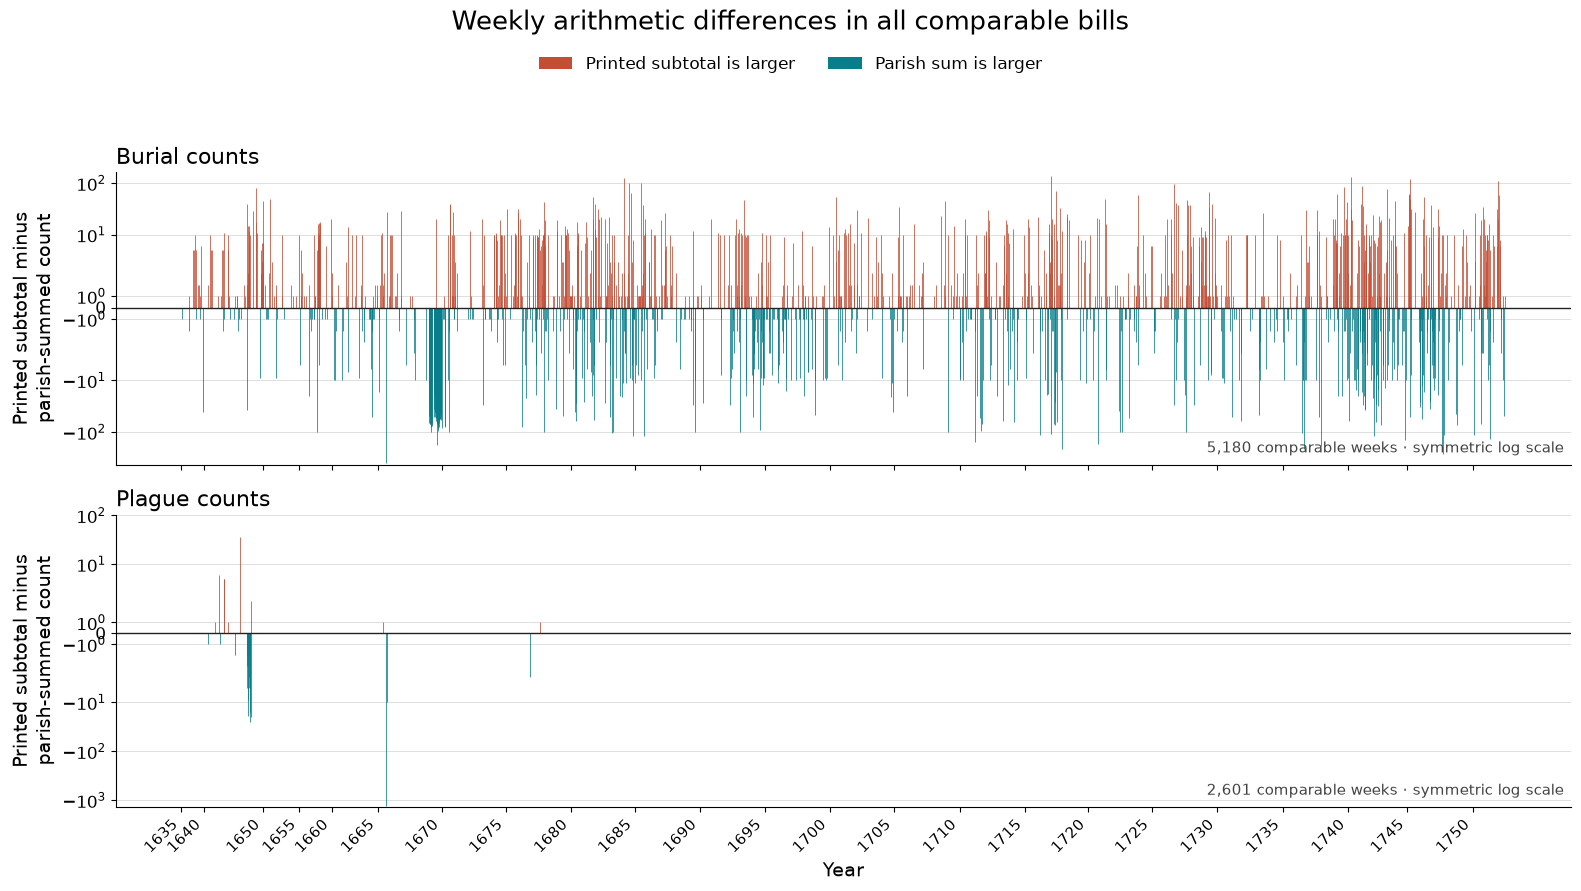

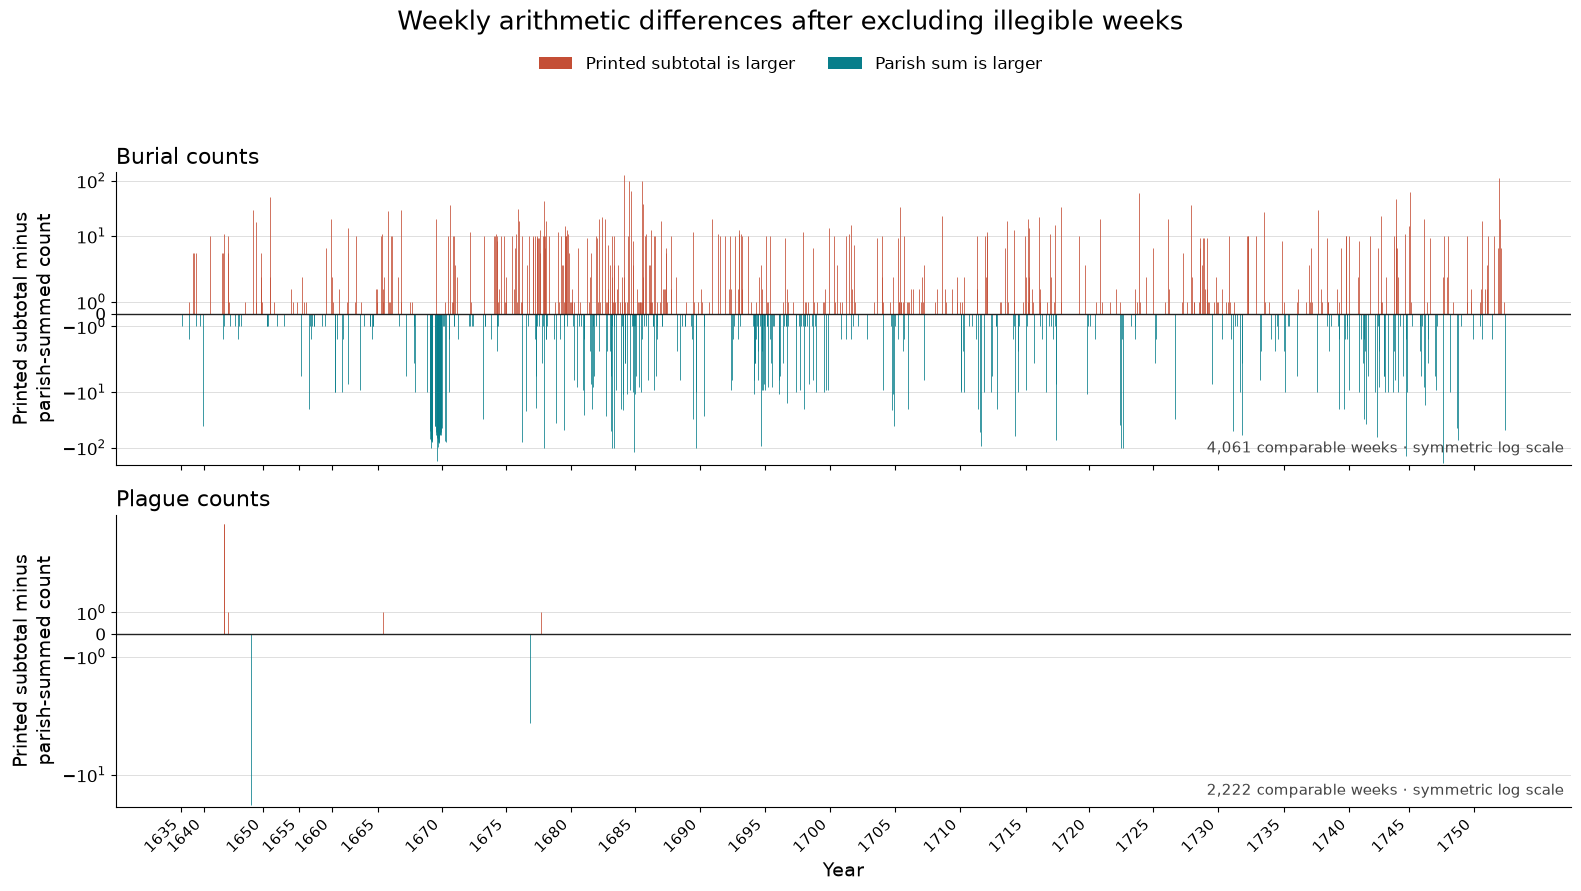

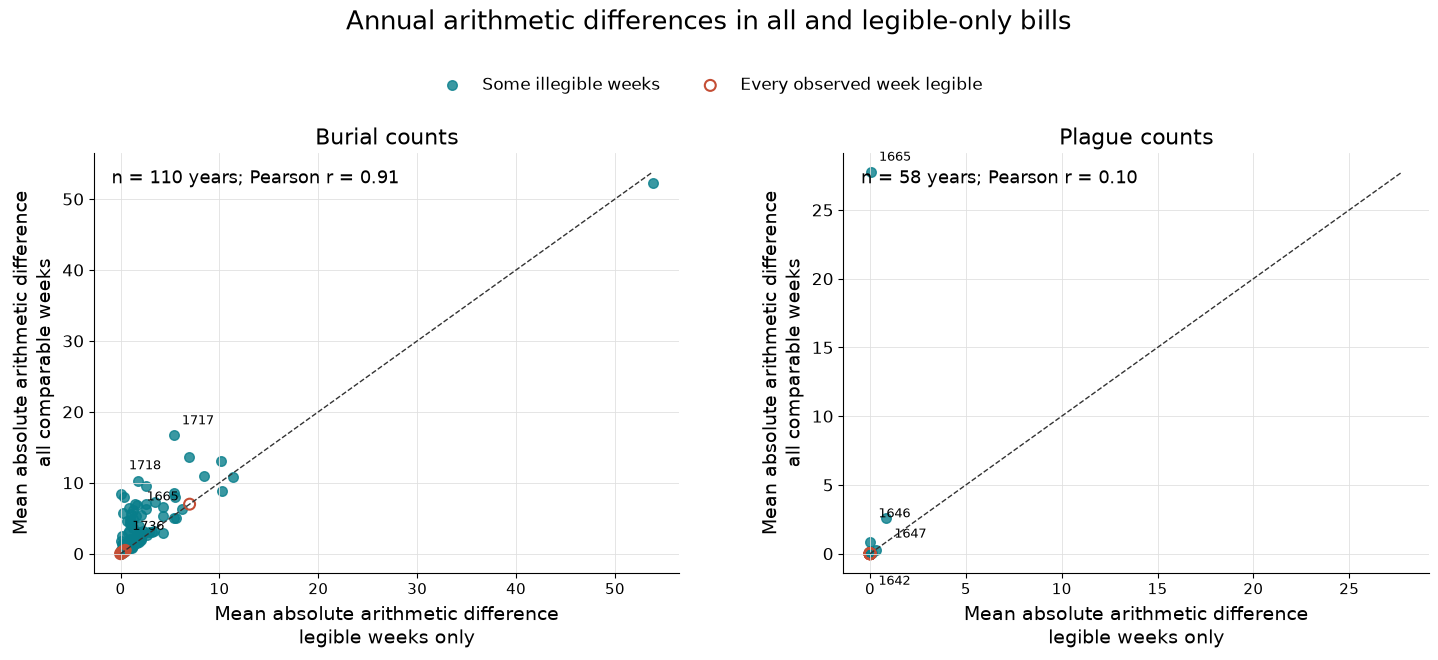

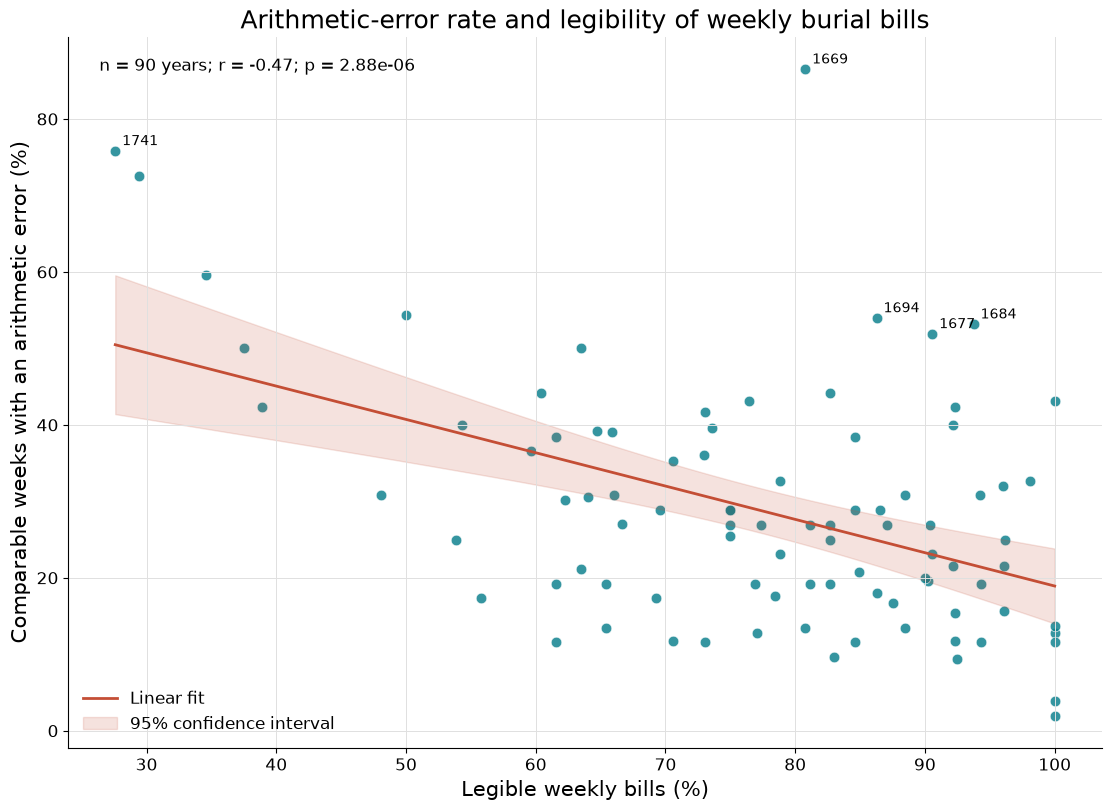

In [1]:
from pathlib import Path
from IPython.display import Image, Markdown, display

from analysis import DATA_REF, run_analysis

HERE = Path.cwd()
results = run_analysis(HERE)
print(f"Archived data commit: {DATA_REF}")
for name, source in results["bundle"].paths.items():
    print(f"{name}: {source}")


## Tables 2–4

The reviewer requested the more precise term *arithmetic error*. The exact caption and table-entry replacements are recorded separately so the manuscript remains untouched in this task.


In [2]:
display(Markdown((HERE / "tables/tables_2_4_terminology.md").read_text()))


# Tables 2–4 terminology revisions

`Manuscript_anonymous.docx` remains unchanged. Apply the replacements below when
the manuscript itself is revised.

## Captions list

- Table 2: **Confirmed and Probable Arithmetic Errors in Week 8 Burial Sums**
- Table 3: **Confirmed Arithmetic Errors in 1640s Burial Sums**
- Table 4: **Remaining Legibility Issues and Confirmed Arithmetic Errors in Plague Sums**

## Table entries

In the explanation columns of Tables 2–4, replace each occurrence of:

- `confirmed math error` with `confirmed arithmetic error`
- `confirmed math errors` with `confirmed arithmetic errors`
- `probable math error` with `probable arithmetic error`
- `plague math error` with `plague arithmetic error`
- `either math error or smear of ink masks a number` with
  `either arithmetic error or smear of ink masks a number`
- `confirmed math ‘error,’` with `confirmed arithmetic ‘error,’`

These are terminology-only changes. The numeric values, row order, and historical
interpretations in the three tables are not changed.


## Revised Figures 4 and 5

Both weekly plots use a larger landscape canvas, readable type, simplified titles, chronological week positions with missing observations left as gaps, and no invisible exact-match legend category. Exact matches lie on the zero line. A symmetric log scale preserves extreme discrepancies while expanding the dense values near zero. The first plot includes all comparable weeks; the second removes every week containing any illegible parish count or subtotal.


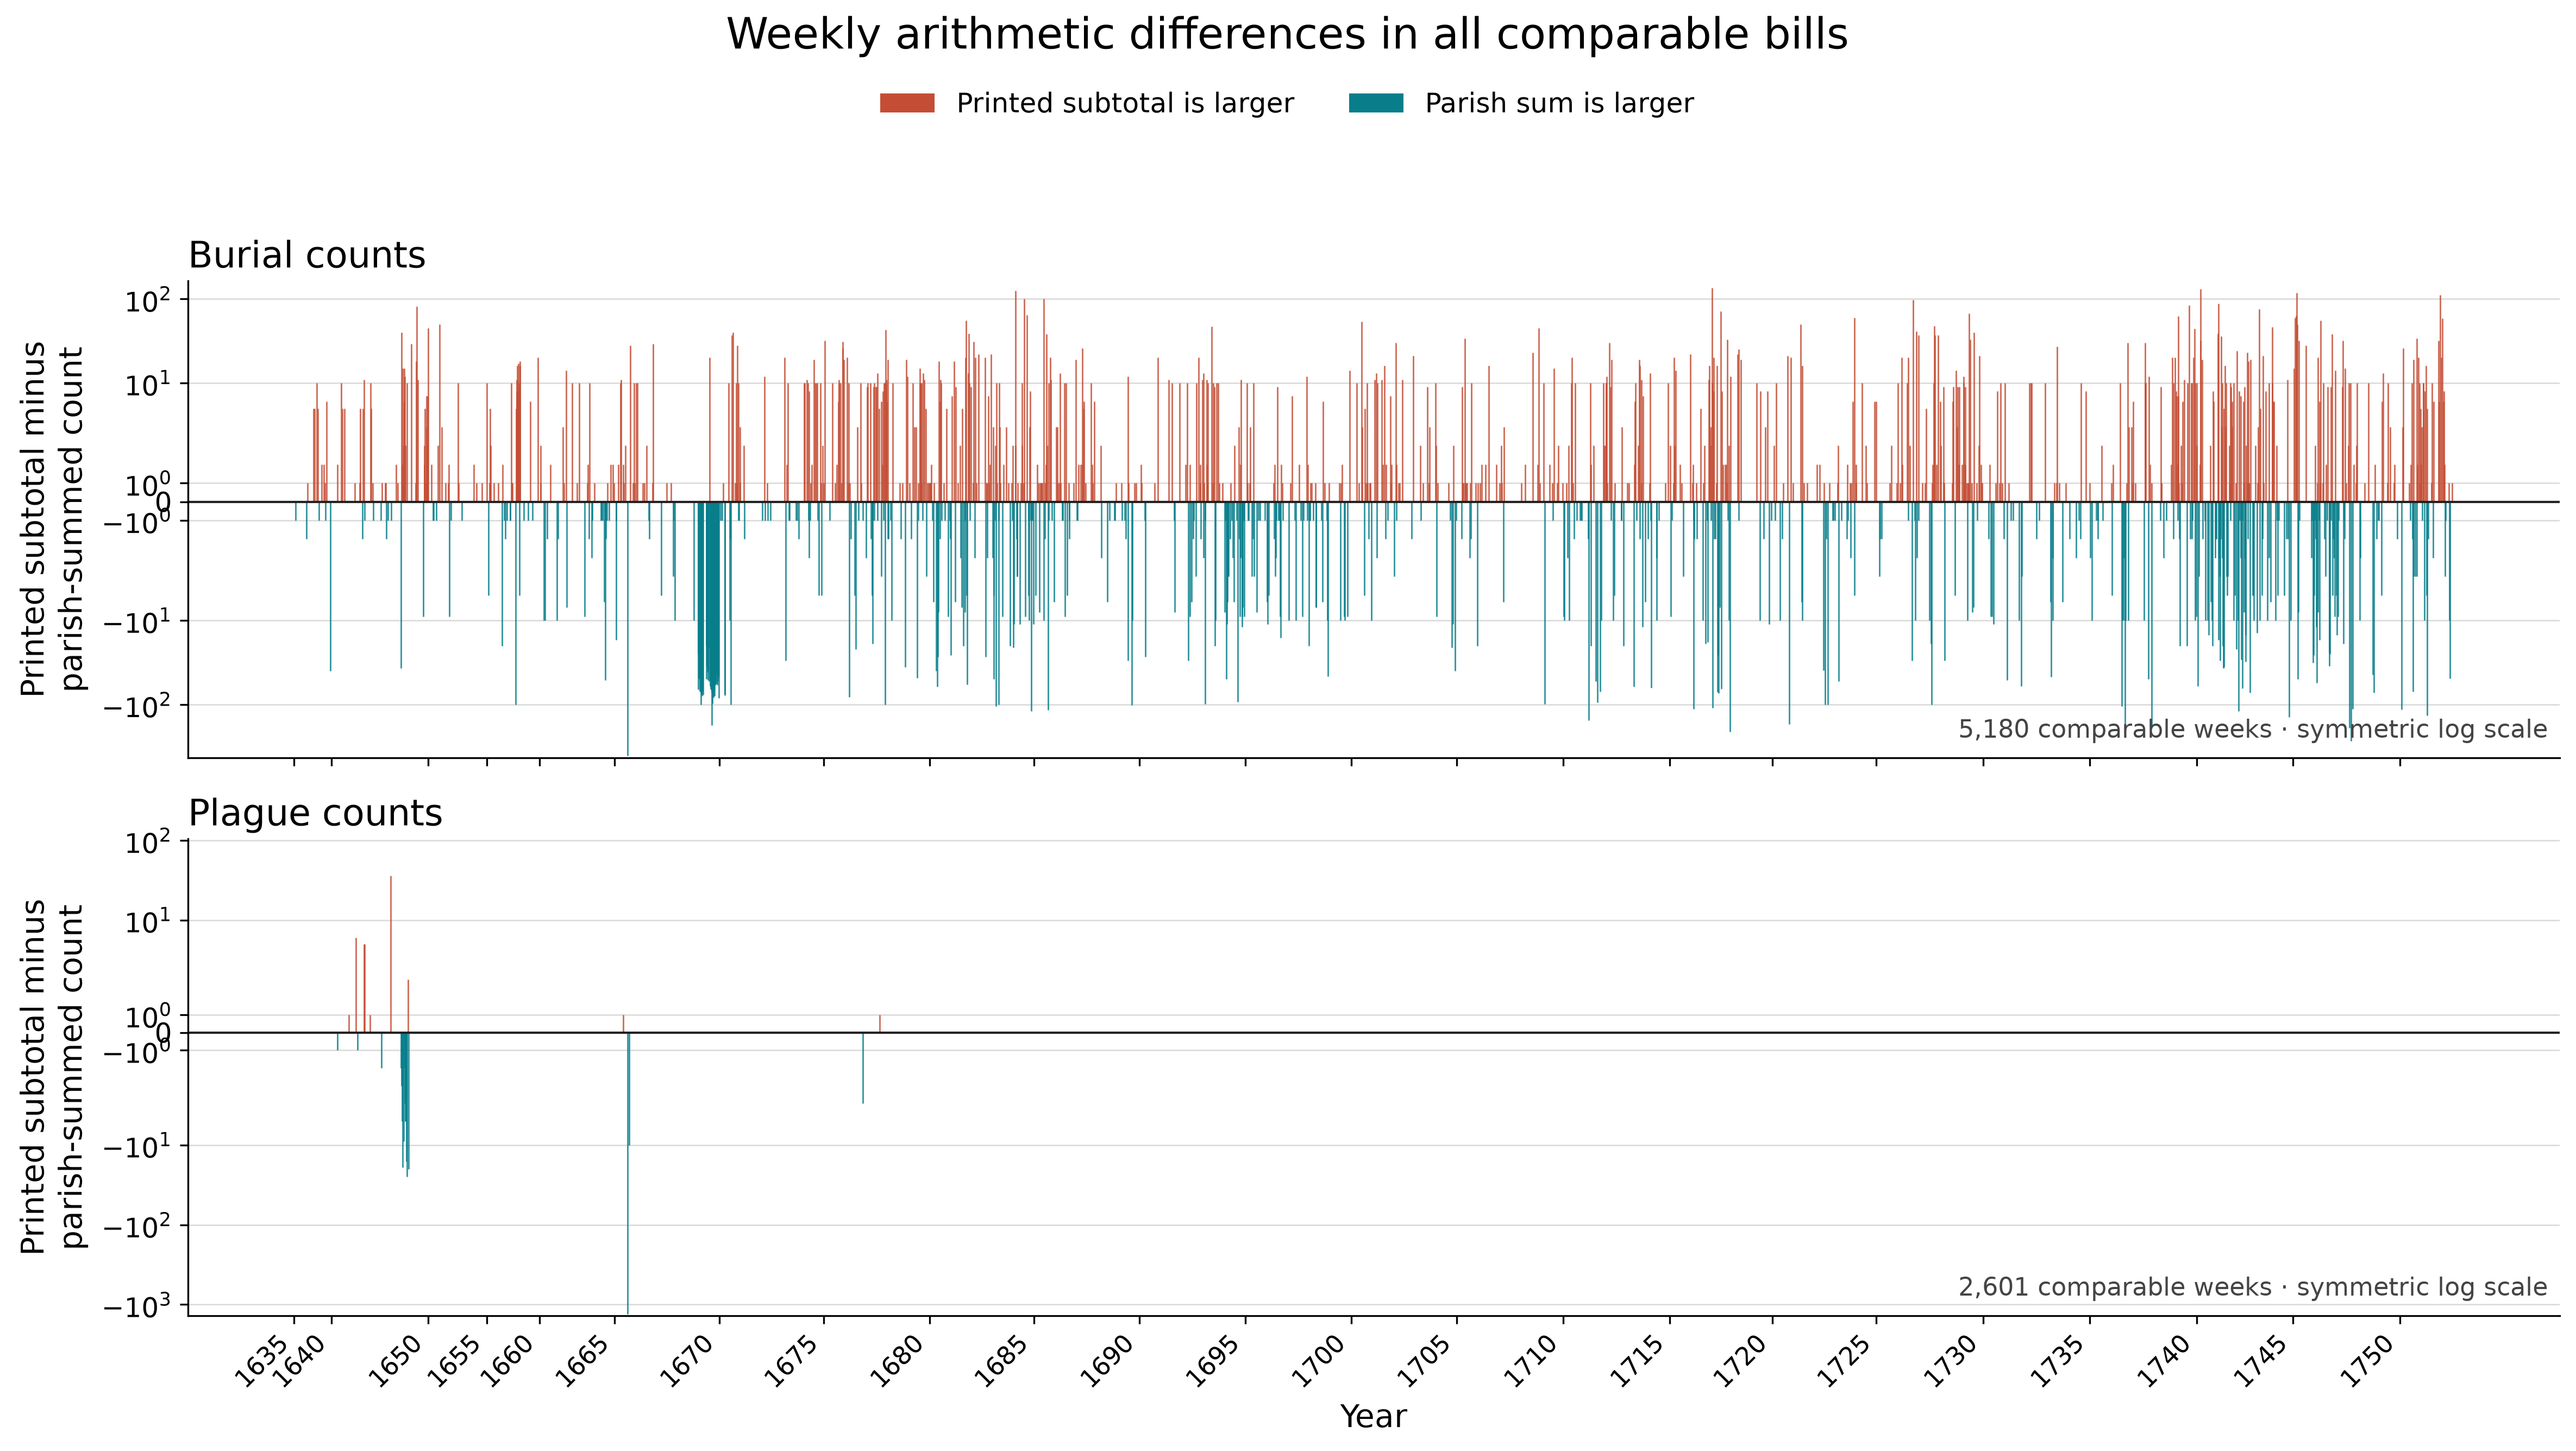

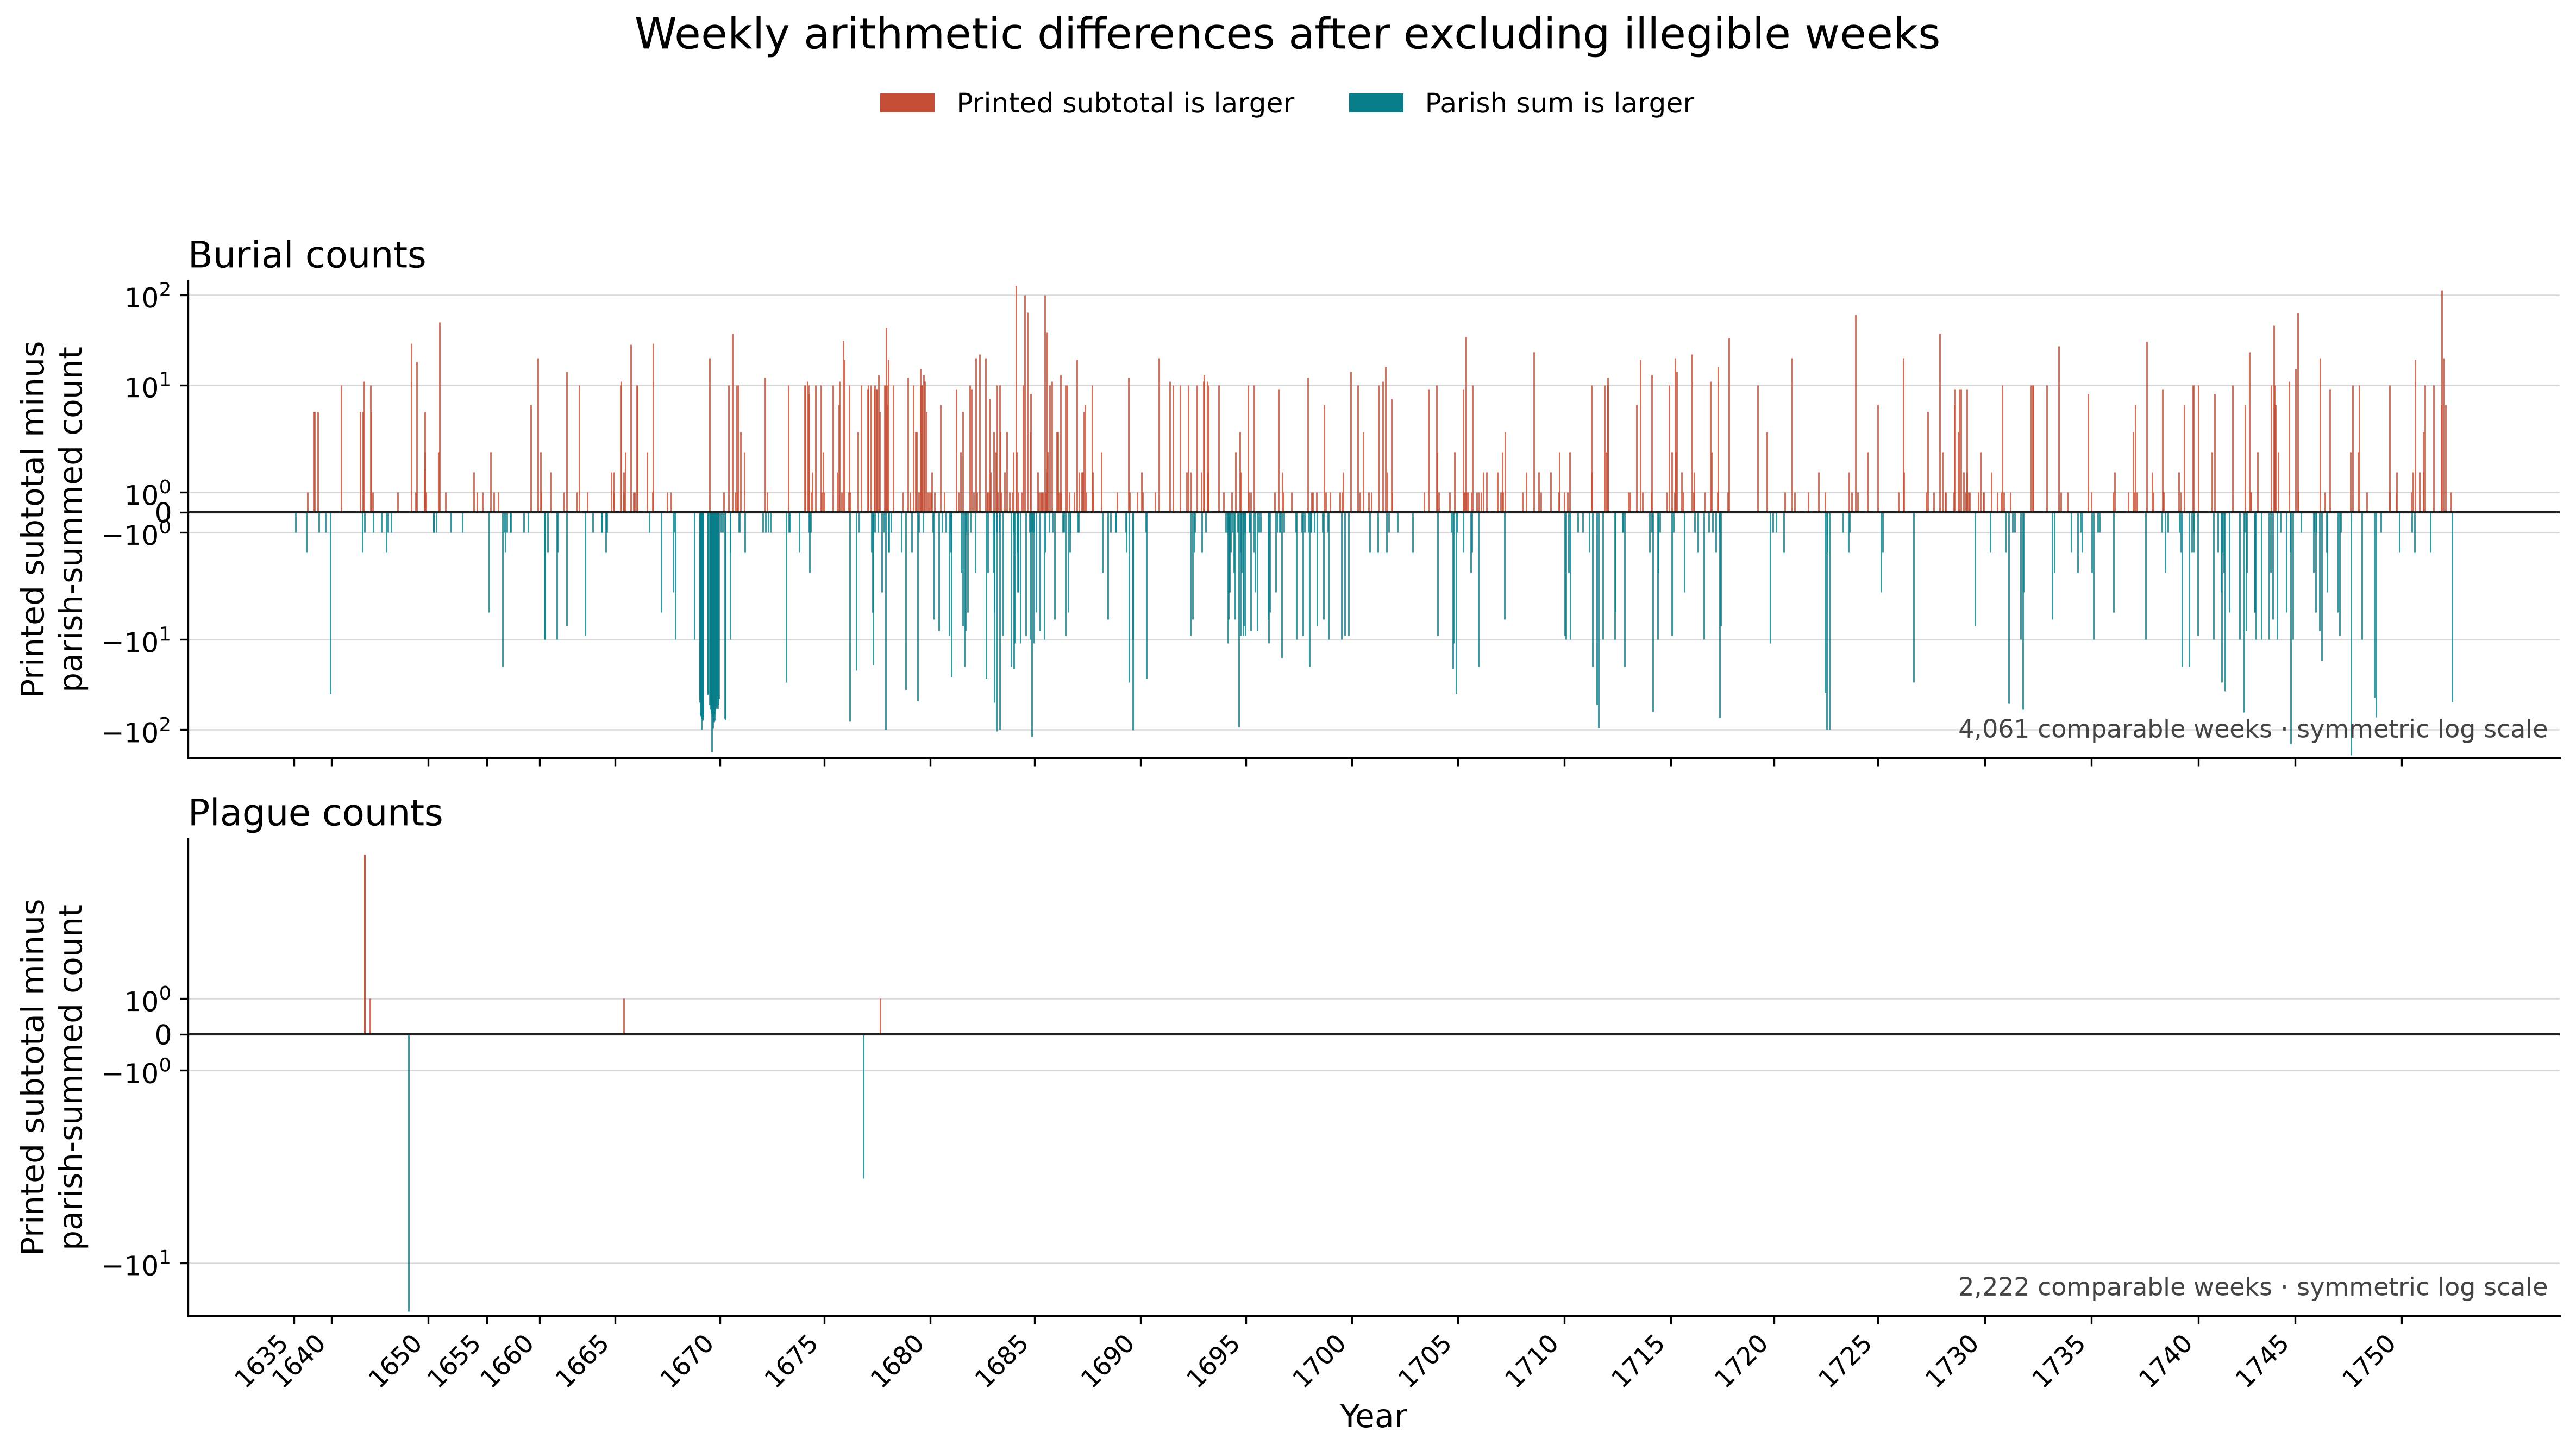

In [3]:
display(Image(filename=HERE / "figures/figure_4_all_bills.png", width=1100))
display(Image(filename=HERE / "figures/figure_5_legible_bills.png", width=1100))


## Direct comparison of Figures 4 and 5

The paired annual scatterplot answers the reviewer's comparison directly. A point on the 1:1 line has the same mean absolute arithmetic difference in the all-data and legible-only analyses. Open points identify years in which every observed week is legible.


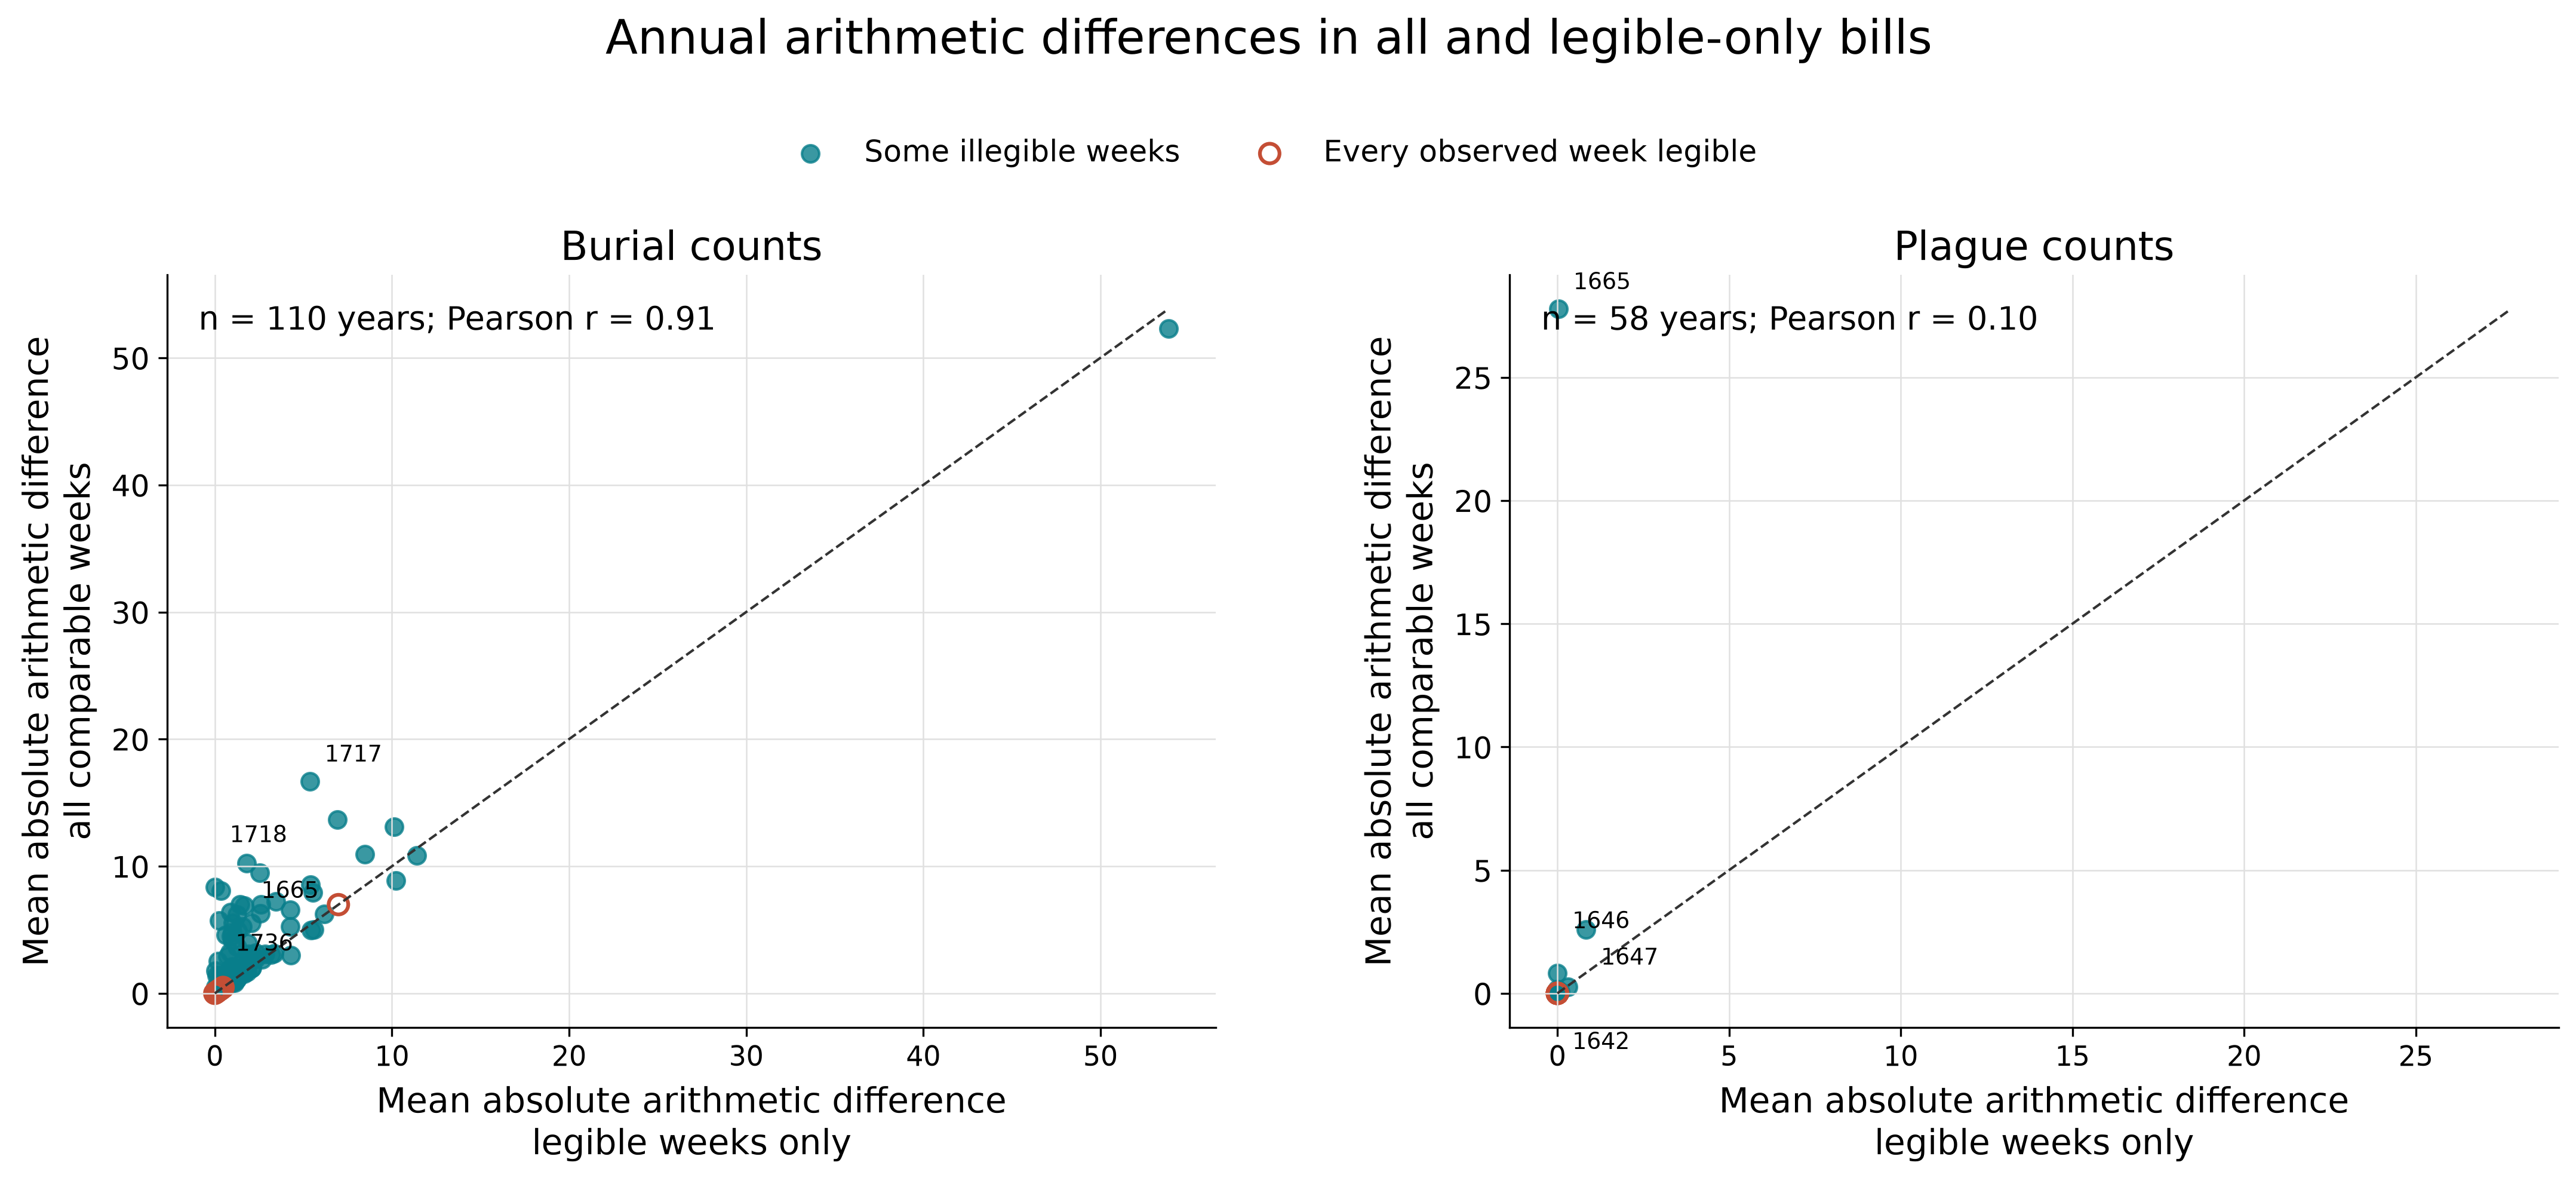

,year,count_type,all_mean_absolute_difference,all_comparable_weeks,legible_mean_absolute_difference,legible_comparable_weeks,total_weeks,illegible_weeks,legible_weeks,percent_legible,fully_legible
0,1635,buried,0.000000,1,0.000000,1,1,0,1,100.000000,True
1,1635,plague,0.000000,1,0.000000,1,1,0,1,100.000000,True
2,1636,buried,0.050000,20,0.055556,18,20,2,18,90.000000,False
3,1636,plague,0.000000,20,0.000000,18,20,2,18,90.000000,False
4,1638,buried,0.393939,33,0.419355,31,33,2,31,93.939394,False
...,...,...,...,...,...,...,...,...,...,...,...
163,1748,buried,2.980769,52,4.281250,32,52,20,32,61.538462,False
164,1749,buried,0.865385,52,0.395349,43,52,9,43,82.692308,False
165,1750,buried,6.403846,52,0.870968,31,52,21,31,59.615385,False
166,1751,buried,5.536585,41,1.037037,27,41,14,27,65.853659,False


In [4]:
display(Image(filename=HERE / "figures/figure_4_5_annual_comparison.png", width=1000))
display(results["annual_comparison"])


## Figure 4 time-series diagnostics

Diagnostics are run separately for signed and absolute arithmetic differences. The sequence is reindexed to the ordered weekly calendar, coverage and the longest uninterrupted observed run are reported, and the Ljung–Box test evaluates white noise on that uninterrupted run. A small ARMA-family grid is fitted only when the run has at least 30 observations and the white-noise null is rejected at p < 0.05.


In [5]:
display(results["diagnostics"])


,count_type,metric,expected_weeks,observed_weeks,coverage_percent,longest_contiguous_run,spearman_time_rho,spearman_time_p,ljung_box_lag,ljung_box_p,seasonal_acf_lag_52,selected_model,model_aic,residual_ljung_box_p,model_adequate
0,buried,signed_difference,5258,5180,98.516546,1690,0.000335,9.807426e-01,10,1.540030e-07,0.032871,"ARIMA(2, 0, 2)",14594.345668,0.000098,False
1,buried,absolute_difference,5258,5180,98.516546,1690,0.064293,3.639113e-06,10,2.754333e-11,0.010368,"ARIMA(1, 0, 2)",14472.804212,0.000067,False
2,plague,signed_difference,5258,2601,49.467478,898,0.051647,8.426475e-03,10,1.000000e+00,-0.000626,not fitted,NaN,NaN,NaN
3,plague,absolute_difference,5258,2601,49.467478,898,-0.131268,1.810504e-11,10,1.000000e+00,-0.001741,not fitted,NaN,NaN,NaN


## Replacement Figure 9

Each point is one year in the manuscript's post-1663 analysis window, when annual coverage is close to complete. Percentage legible weeks is on the x-axis and the annual burial arithmetic-error rate is on the y-axis. A fitted linear relationship and 95% confidence interval appear only when the prespecified p < 0.05 threshold is met.


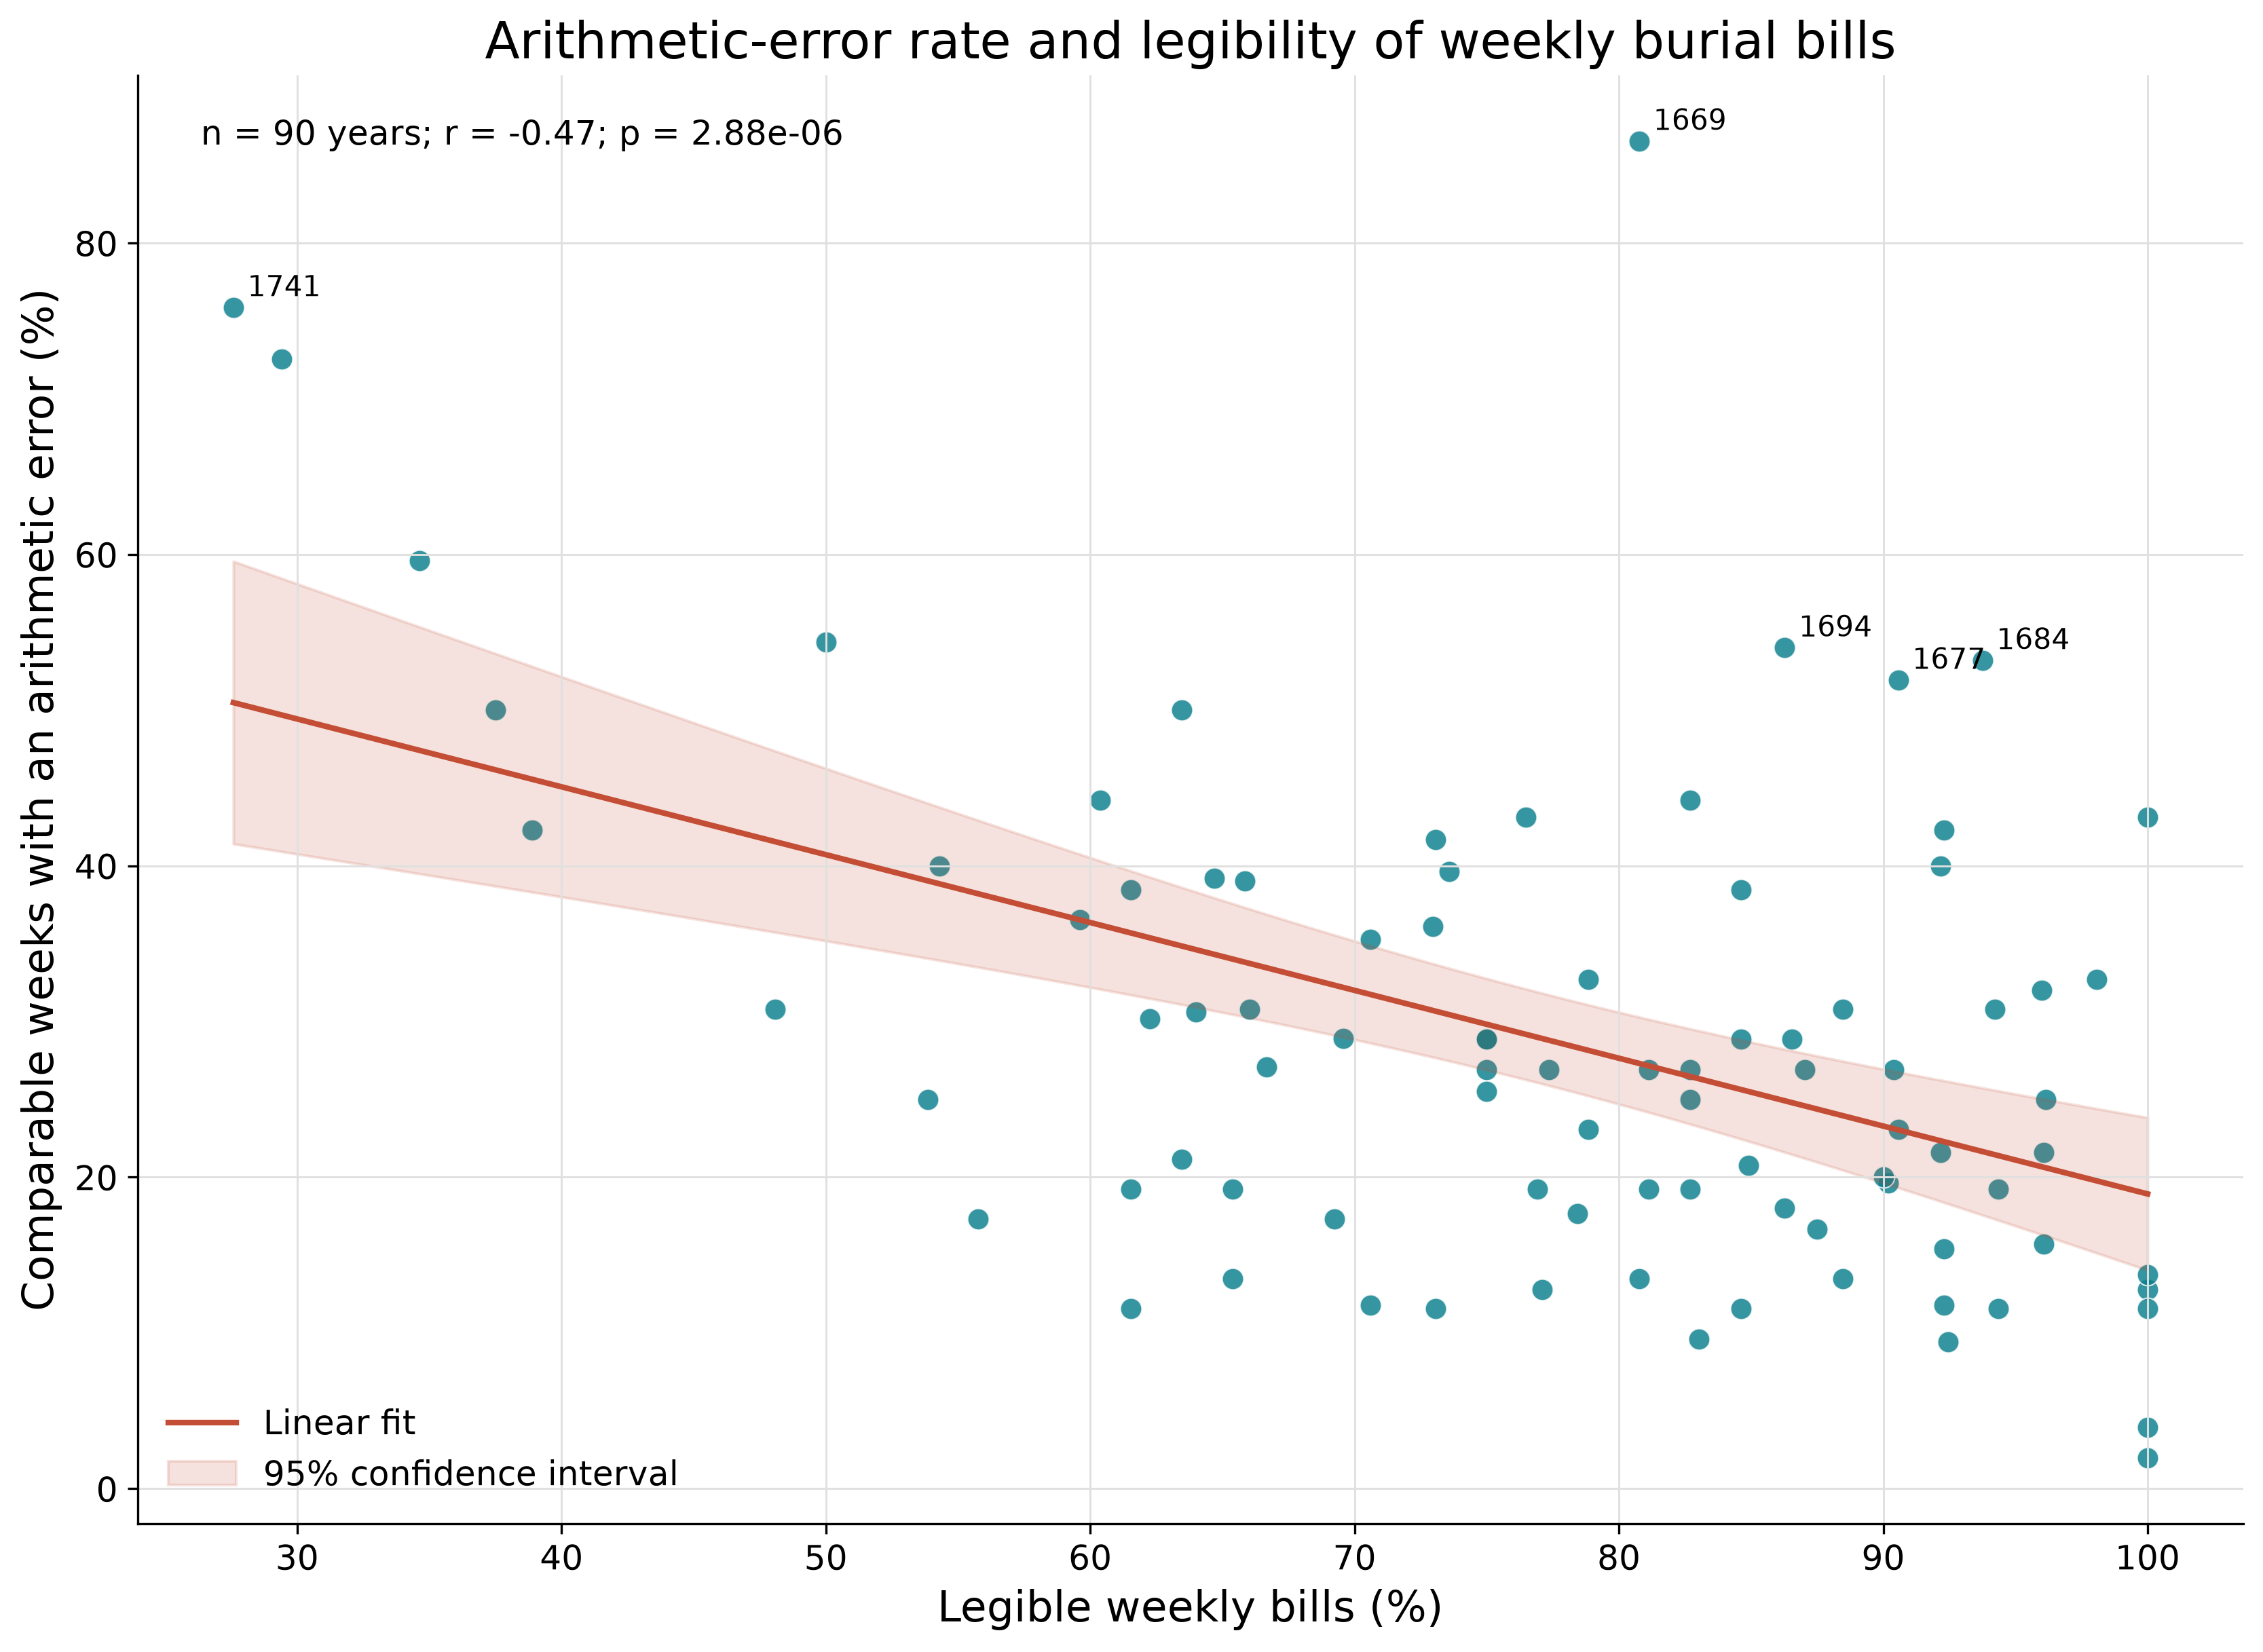

,year,comparable_weeks,arithmetic_errors,arithmetic_error_rate,total_weeks,illegible_weeks,legible_weeks,percent_legible,fully_legible
0,1663,52,10,19.230769,52,18,34,65.384615,False
1,1664,52,14,26.923077,52,13,39,75.000000,False
2,1665,48,13,27.083333,48,16,32,66.666667,False
3,1666,50,9,18.000000,51,7,44,86.274510,False
4,1667,47,6,12.765957,48,0,48,100.000000,True
...,...,...,...,...,...,...,...,...,...
85,1748,52,10,19.230769,52,20,32,61.538462,False
86,1749,52,10,19.230769,52,9,43,82.692308,False
87,1750,52,19,36.538462,52,21,31,59.615385,False
88,1751,41,16,39.024390,41,14,27,65.853659,False


{'n': 90,
 'slope': np.float64(-0.4357932289515433),
 'intercept': np.float64(62.50092073964068),
 'r': np.float64(-0.4704711645237935),
 'p': np.float64(2.8811353291365324e-06),
 'fit_plotted': np.True_}

In [6]:
display(Image(filename=HERE / "figures/figure_9_legibility_error_rate.png", width=850))
display(results["figure_9_data"])
results["figure_9_stats"]


## Concise results for the revision narrative


In [7]:
display(Markdown((HERE / "tables/revision_results.md").read_text()))


# Revision analysis results

## Figures 4 and 5 annual comparison

- Buried: 110 paired years; Pearson r = 0.915, p = 2.65e-44; 8 fully legible years.
- Plague: 58 paired years; Pearson r = 0.100, p = 0.456; 8 fully legible years.

## Figure 9 replacement

- 90 annual observations; linear slope = -0.436; Pearson r = -0.470; p = 2.88e-06.
- A fitted line and 95% confidence interval were plotted.

## Figure 4 time-series diagnostics

- buried, signed_difference: 5180/5258 weeks observed (98.5%); longest contiguous run 1690; Ljung-Box p = 1.54e-07; ARIMA(2, 0, 2) candidate was inadequate because residual autocorrelation remained (p = 9.76e-05).
- buried, absolute_difference: 5180/5258 weeks observed (98.5%); longest contiguous run 1690; Ljung-Box p = 2.75e-11; ARIMA(1, 0, 2) candidate was inadequate because residual autocorrelation remained (p = 6.66e-05).
- plague, signed_difference: 2601/5258 weeks observed (49.5%); longest contiguous run 898; Ljung-Box p = 1; no ARMA-family model fitted.
- plague, absolute_difference: 2601/5258 weeks observed (49.5%); longest contiguous run 898; Ljung-Box p = 1; no ARMA-family model fitted.
